# M1A7 - Fundamentos de Filtros Espaciais e Convoluções

Na aula de hoje vamos aprender como fazer convoluções utilizando [OpenCV](https://opencv.org/).

Esse notebook está estruturado da seguinte forma.

- Introdução
- Convoluções
- Próximos passos
- Atividade Complementares

## Introdução

Instalação para os que ainda não possuem a biblioteca instalada.

In [7]:
!pip install opencv-python

Importar as bibliotecas e Ler Imagens do Disco

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [9]:
# TODO Atualize o path da imagem.
image = cv2.imread("bahia.jpeg")

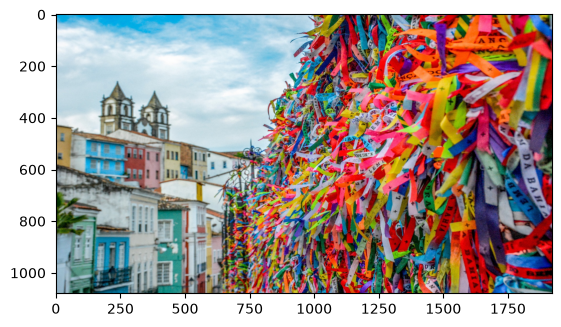

In [10]:
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

## Convoluções

Para realizar uma convolução é necessário definir primeiro um kernel.

In [11]:
x_canny = np.array([[-1, 0, 1],[-2, 0, 2],[-1, 0, 1]])
y_canny = np.array([[-1, -2, -1],[0, 0, 0], [1, 2, 1]])

sharp = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])

print(f"x canny kernel:\n{x_canny}")

print(f"y canny kernel:\n{y_canny}")

print(f"sharp kernel:\n{sharp}")

x canny kernel:
[[-1  0  1]
 [-2  0  2]
 [-1  0  1]]
y canny kernel:
[[-1 -2 -1]
 [ 0  0  0]
 [ 1  2  1]]
sharp kernel:
[[ 0 -1  0]
 [-1  5 -1]
 [ 0 -1  0]]


Agora vamos aplicar esses kernels e observar como eles modificam as imagens.

Para aplicar podemos utilizar a função `cv2.filter2D` para convoluir a imagens com os kernels que fizemos.

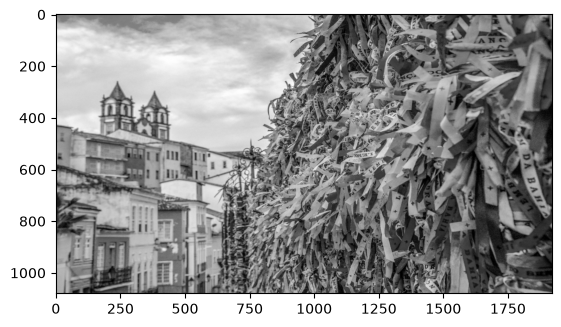

In [12]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
plt.imshow(gray, cmap="gray")

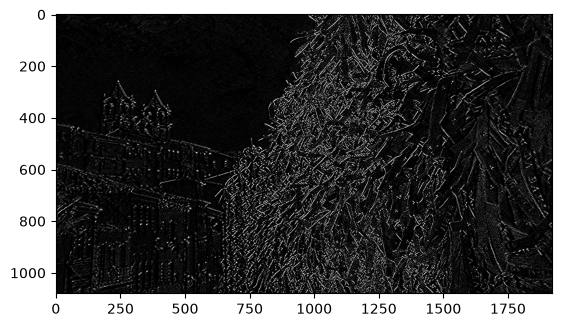

In [13]:
image_canny = cv2.filter2D(gray, -1, x_canny)
image_canny = cv2.filter2D(image_canny, -1, y_canny)
plt.imshow(image_canny, cmap="gray")

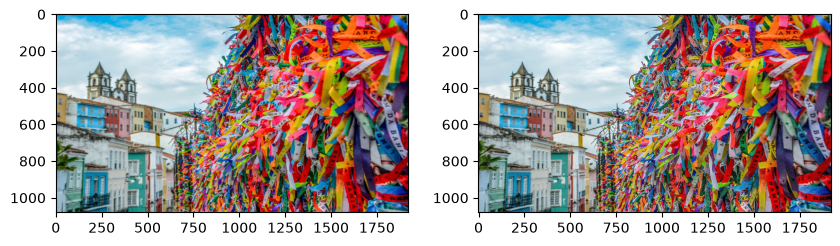

In [14]:
image_sharp = cv2.filter2D(image, -1, sharp)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 8))
axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
axes[1].imshow(cv2.cvtColor(image_sharp, cv2.COLOR_BGR2RGB))
plt.show()

E assim terminamos a prática de hoje.

## Próximos Passos e Referências

Nas próximas práticas iremos avançar ainda mais no mundo de Visão Computacional.

Uma lista não exaustiva de referências segue:

- https://opencv.org/
- https://learnopencv.com/blogs/
- https://pyimagesearch.com/

## Atividades Complementares (Opicional)

- [ ] Leia a outra imagem do arquivo `rio.jpeg` e rode todos os comandos.
- [ ] Tente alterar os valores nos kernels e veja como a alteração reflete na imagem.

---------------------------------------------------------------------------------------------------------------

- [x] Leia a outra imagem do arquivo `rio.jpeg` e rode todos os comandos.

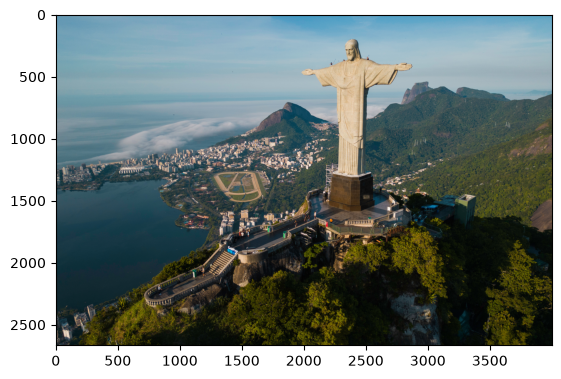

In [15]:
image = cv2.imread("rio.jpeg")
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

x canny kernel:
[[-1  0  1]
 [-2  0  2]
 [-1  0  1]]
y canny kernel:
[[-1 -2 -1]
 [ 0  0  0]
 [ 1  2  1]]
sharp kernel:
[[ 0 -1  0]
 [-1  5 -1]
 [ 0 -1  0]]


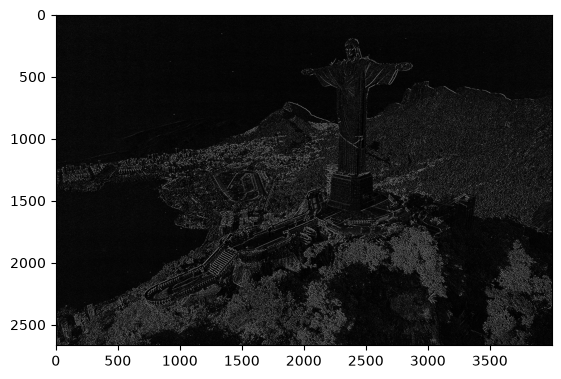

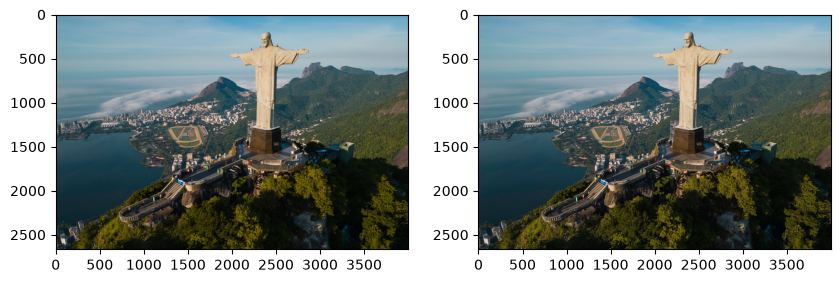

In [16]:
x_canny = np.array([[-1, 0, 1],[-2, 0, 2],[-1, 0, 1]])
y_canny = np.array([[-1, -2, -1],[0, 0, 0], [1, 2, 1]])

sharp = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])

print(f"x canny kernel:\n{x_canny}")

print(f"y canny kernel:\n{y_canny}")

print(f"sharp kernel:\n{sharp}")

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
plt.imshow(gray, cmap="gray")

image_canny = cv2.filter2D(gray, -1, x_canny)
image_canny = cv2.filter2D(image_canny, -1, y_canny)
plt.imshow(image_canny, cmap="gray")

image_sharp = cv2.filter2D(image, -1, sharp)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 8))
axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
axes[1].imshow(cv2.cvtColor(image_sharp, cv2.COLOR_BGR2RGB))
plt.show()


- [X] Tente alterar os valores nos kernels e veja como a alteração reflete na imagem.

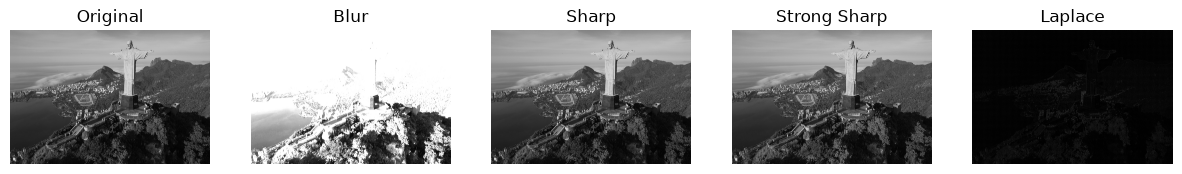

In [51]:
kernels = {
    "Original": None,
    "Blur": np.ones((8,8))/16,
    "Sharp": np.array([[0,-1,0],[-1,5,-1],[0,-1,0]]),
    "Strong Sharp": np.array([[-1,-1,-1],[-1,9,-1],[-1,-1,-1]]),
    "Laplace": np.array([[0,-1,0],[-1,4,-1],[0,-1,0]])
}

fig, axes = plt.subplots(1, len(kernels), figsize=(15,5))

for ax, (name, kernel) in zip(axes, kernels.items()):
    if kernel is None:
        result = gray
    else:
        result = cv2.filter2D(gray, -1, kernel)

    ax.imshow(result, cmap="gray")
    ax.set_title(name)
    ax.axis("off")

plt.show()

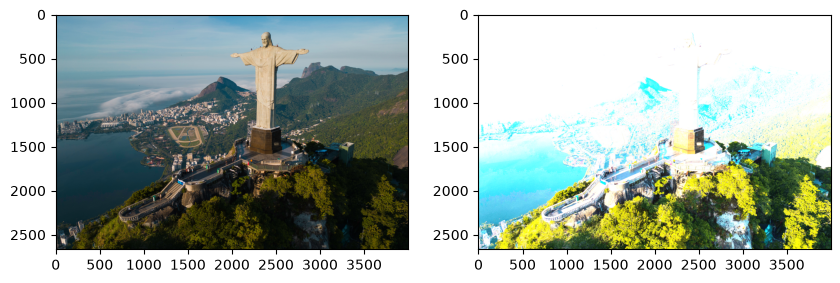

In [29]:
image_sharp = cv2.filter2D(image, -1, kernels["Sharp"])
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 8))
axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
axes[1].imshow(cv2.cvtColor(image_sharp, cv2.COLOR_BGR2RGB))
plt.show()

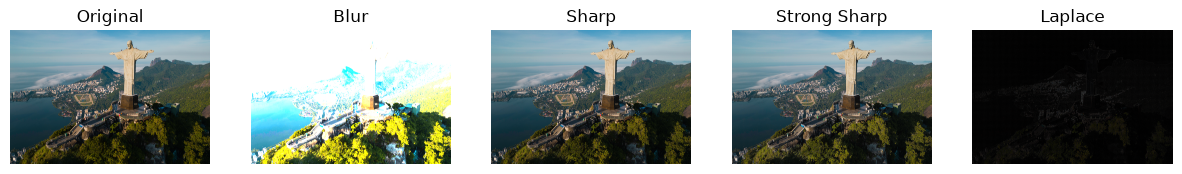

In [52]:
fig, axes = plt.subplots(1, len(kernels), figsize=(15,5))

for ax, (name, kernel) in zip(axes, kernels.items()):

    if kernel is None:
        result = image.copy()
    else:
        result = cv2.filter2D(image, -1, kernel)

    ax.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    ax.set_title(name)
    ax.axis("off")

plt.show()